In [ ]:
import sys

sys.path.insert(0, "..")

In [ ]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

from config.defaults import DefaultParams, InferenceParams, ModelParams, TrainingParams

In [ ]:
from src.data import test_loader, train_loader, val_loader, vocab

print(f"词表大小: {len(vocab)}")
print(f"训练 batch 数: {len(train_loader)}")
print(f"验证 batch 数: {len(val_loader)}")
print(f"测试 batch 数: {len(test_loader)}")
print(
    f"总字符数: {len(train_loader.dataset.indices) + len(val_loader.dataset.indices) + len(test_loader.dataset.indices)}"
)

词表大小: 65
训练 batch 数: 1395
验证 batch 数: 175
测试 batch 数: 175
总字符数: 1115393


In [ ]:
for i, (char, index) in enumerate(list(vocab.char2idx.items())[:15]):
    print(f"{char!r} -> {index}")
print(f"{' '.join(vocab.char2idx.keys())}")

'\n' -> 0
' ' -> 1
'!' -> 2
'$' -> 3
'&' -> 4
"'" -> 5
',' -> 6
'-' -> 7
'.' -> 8
'3' -> 9
':' -> 10
';' -> 11
'?' -> 12
'A' -> 13
'B' -> 14

   ! $ & ' , - . 3 : ; ? A B C D E F G H I J K L M N O P Q R S T U V W X Y Z a b c d e f g h i j k l m n o p q r s t u v w x y z


In [ ]:
x, y = next(iter(train_loader))
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

print(f"Input sequence: {vocab.decode(x[0].tolist())}")
print(f"Target sequence: {vocab.decode(y[0].tolist())}")

x shape: torch.Size([64, 100])
y shape: torch.Size([64, 100])
Input sequence: r love;
To both their deaths thou shalt be accessary.

LADY ANNE:
I would I knew thy heart.

GLOUCES
Target sequence:  love;
To both their deaths thou shalt be accessary.

LADY ANNE:
I would I knew thy heart.

GLOUCEST


In [ ]:
class CharRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(vocab), ModelParams.EMBEDDING_DIM)
        self.rnn = nn.LSTM(
            input_size=ModelParams.EMBEDDING_DIM,  # 输入维度
            hidden_size=ModelParams.HIDDEN_DIM,  # 隐藏层维度
            num_layers=ModelParams.NUM_LAYERS,  # 隐藏层数量
            dropout=ModelParams.DROPOUT,  # dropout 概率
            batch_first=True,  # 输入和输出的 batch 维度在第一维
        )
        self.fc = nn.Linear(ModelParams.HIDDEN_DIM, len(vocab))  # 输出层

    def forward(self, x, hidden=None):
        x = self.embedding(
            x
        )  # (batch_size, seq_length) -> (batch_size, seq_length, embedding_dim)
        output, hidden = self.rnn(
            x, hidden
        )  # (batch_size, seq_length, embedding_dim) -> (batch_size, seq_length, hidden_dim)
        output = self.fc(
            output
        )  # (batch_size, seq_length, hidden_dim) -> (batch_size, seq_length, vocab_size)
        return output, hidden

In [ ]:
model = CharRNN().to(DefaultParams.DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"模型总参数量: {total_params}")
print(f"词表大小: {len(vocab)}")
print(f"嵌入维度: {ModelParams.EMBEDDING_DIM}")
print(f"隐藏层维度: {ModelParams.HIDDEN_DIM}")
print(f"层数: {ModelParams.NUM_LAYERS}")
model

模型总参数量: 1086017
词表大小: 65
嵌入维度: 256
隐藏层维度: 256
层数: 2


CharRNN(
  (embedding): Embedding(65, 256)
  (rnn): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)

In [ ]:
def init_hidden(batch_size):
    """
    初始化隐藏状态
    """
    device = DefaultParams.DEVICE
    # LSTM 的隐藏状态由 (h, c) 组成，每个都是 (num_layers, batch_size, hidden_dim)
    h = torch.zeros(ModelParams.NUM_LAYERS, batch_size, ModelParams.HIDDEN_DIM).to(
        device
    )
    c = torch.zeros(ModelParams.NUM_LAYERS, batch_size, ModelParams.HIDDEN_DIM).to(
        device
    )
    return (h, c)


def calculate_perplexity(loss):
    """
    计算 perplexity
    perplexity = exp(loss)
    """
    return math.exp(loss)

In [ ]:
x, y = next(iter(train_loader))
x, y = x.to(DefaultParams.DEVICE), y.to(DefaultParams.DEVICE)

hidden = init_hidden(x.size(0))
output, hidden = model(x, hidden)
print(f"输入 shape: {x.shape}")  # (batch_size, seq_length)
print(f"输出 shape: {output.shape}")  # (batch_size, seq_length, vocab_size)
print(f"期望: ({x.size(0)}, {x.size(1)}, {len(vocab)})")

# 验证shape是否正确
assert output.shape == (x.size(0), x.size(1), len(vocab)), "输出 shape 不正确"
print("输出 shape 正确")

输入 shape: torch.Size([64, 100])
输出 shape: torch.Size([64, 100, 65])
期望: (64, 100, 65)
输出 shape 正确


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=TrainingParams.LEARNING_RATE,
    weight_decay=TrainingParams.WEIGHT_DECAY,
)

history = {
    "train_loss": [],
    "train_perplexity": [],
    "val_loss": [],
    "val_perplexity": [],
}
epochs = TrainingParams.EPOCHS

for epoch in range(1, epochs + 1):
    # 训练阶段
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"[Train] Epoch {epoch:2d}/{epochs}")
    for x, y in pbar:
        x, y = x.to(DefaultParams.DEVICE), y.to(DefaultParams.DEVICE)
        hidden = init_hidden(x.size(0))

        optimizer.zero_grad()
        output, hidden = model(x, hidden)
        loss = criterion(
            output.transpose(1, 2), y
        )  # (batch_size, vocab_size, seq_length) vs (batch_size, seq_length)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), TrainingParams.CLIP_GRAD)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(
            {
                "loss": f"{loss.item():.4f}",
                "perplexity": f"{calculate_perplexity(loss.item()):.4f}",
            }
        )

    avg_train_loss = total_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)
    history["train_perplexity"].append(calculate_perplexity(avg_train_loss))

    with torch.no_grad():
        model.eval()
        total_val_loss = 0
        pbar = tqdm(val_loader, desc=f"[Val] Epoch {epoch:2d}/{epochs}")
        for x, y in pbar:
            x, y = x.to(DefaultParams.DEVICE), y.to(DefaultParams.DEVICE)
            hidden = init_hidden(x.size(0))
            output, hidden = model(x, hidden)
            val_loss = criterion(output.transpose(1, 2), y)
            total_val_loss += val_loss.item()
            pbar.set_postfix(
                {
                    "loss": f"{val_loss.item():.4f}",
                    "perplexity": f"{calculate_perplexity(val_loss.item()):.4f}",
                }
            )

    avg_val_loss = total_val_loss / len(val_loader)
    history["val_loss"].append(avg_val_loss)
    history["val_perplexity"].append(calculate_perplexity(avg_val_loss))

[Val] Epoch 20/20: 100%|██████████| 175/175 [00:06<00:00, 26.32it/s, loss=1.4746, perplexity=4.3693] 


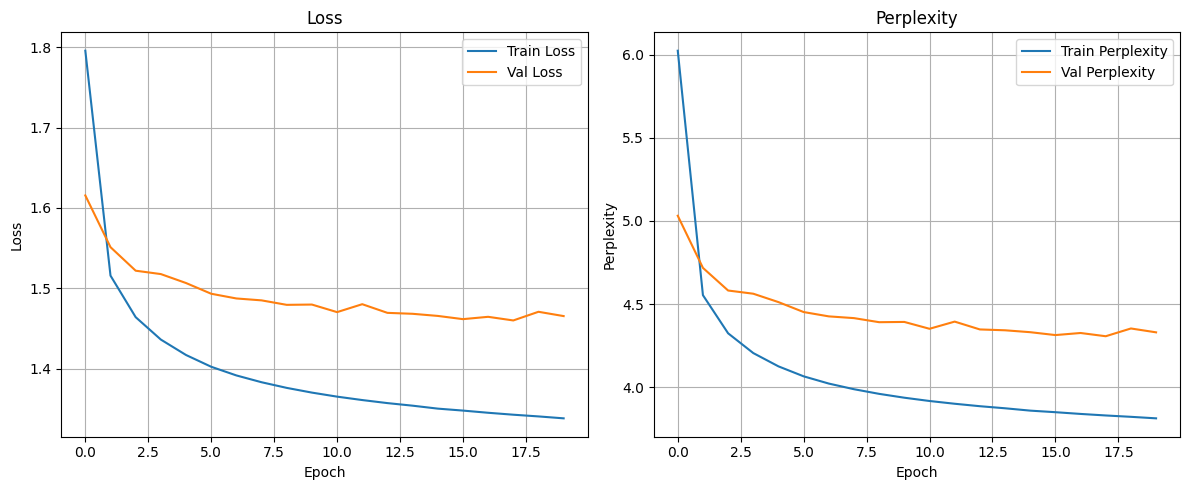

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["val_loss"], label="Val Loss")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history["train_perplexity"], label="Train Perplexity")
ax[1].plot(history["val_perplexity"], label="Val Perplexity")
ax[1].set_title("Perplexity")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Perplexity")
ax[1].legend()
ax[1].grid(True)


plt.tight_layout()
plt.show()

In [ ]:
def inference(prompt, max_length=100, temperature=InferenceParams):
    model.eval()
    # 将 prompt 转换为索引
    indices = vocab.encode(prompt)
    # 从 prompt 的索引开始生成
    result = list(indices)
    # 初始化隐藏状态
    hidden = init_hidden(1)  # batch_size=1
    # 喂入 prompt 的索引
    with torch.no_grad():
        for index in indices[:-1]:  # 先喂入 prompt 的前 n-1 个字符
            input_tensor = torch.tensor(
                [[index]], device=DefaultParams.DEVICE
            )  # (1, 1)
            _, hidden = model(input_tensor, hidden)

        # 从 prompt 的最后一个字符开始生成
        current = indices[-1]
        for _ in range(max_length):
            x = torch.tensor([[current]], device=DefaultParams.DEVICE)  # (1, 1)
            output, hidden = model(x, hidden)  # output: (1, 1, vocab_size)
            probs = F.softmax(output[0, 0] / temperature, dim=0)  # (vocab_size,)
            current = torch.multinomial(
                probs, num_samples=1
            ).item()  # 从概率分布中采样下一个字符索引
            result.append(current)

    return vocab.decode(result)


prompt = "First Citizen: "
generated_text = inference(prompt, max_length=500, temperature=0.8)
print(generated_text)

First Citizen: I say 'twas as no out a read,
Where his true enemy with their charges of her,
And throw their eye the ground. You care with summer
Than each upon the morn of those, and I,
I'll seek it for your whome to the earth.
Was we't a mind of this?

PAULINA:
That's the consul.

SICINIUS:
For this can prich my brother,
With this dread spotor.

PETER:
Now, this is the royal heavy of the off,
Who brings a very death, which to the sire
To murder my talk, and I would to-king,
He should be such a fortune's more


In [ ]:
prompt = "First Citizen:"
for temp in [0.3, 0.6, 0.8, 1.0, 1.2]:
    print(f"\n{'=' * 60}")
    print(f"temperature = {temp}")
    print(f"{'=' * 60}")
    print(inference(prompt, 200, temp))


temperature = 0.3
First Citizen:
Why, there is the consul.

CORIOLANUS:
I will not speak a word.

MENENIUS:
How should you be the fortune of the world?

CORIOLANUS:
I would I see the state, the state of the presence
To see the time 

temperature = 0.6
First Citizen:
Here are the reverence of the course of the earth to have
look to you on the more--to his presence.

SICINIUS:
This is my life in my son, and stand not to her
honour and his power.

MERENIUS:
O, go, 

temperature = 0.8
First Citizen:
The trust a sheep-but as my consuls author in her spring.
I am his suffer big the daughter band.
E, having made her, stand in her than thousands,
Sous the present through what will did Clarence are?


temperature = 1.0
First Citizen:
But they must go to you: or I set up his dath,
Not for by vent with such a letter and
That comes him on our womb by from his lands.
So am her gallest for no time with on thisin thinking?
Is thou to s

temperature = 1.2
First Citizen:
O there should
Your honestive 